# Arabic Intent Classification — Egyptian Call-Centre Transcripts
### Track C: Few-Shot Prompting



**Model:** `Qwen/Qwen2.5-7B-Instruct`, loaded in 4-bit

## 1. Environment Setup

In [1]:
!nvidia-smi || echo "No GPU detected -- a 7B model needs a GPU to run at a usable latency; CPU inference will be extremely slow."


Tue Sep  1 21:19:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q transformers accelerate bitsandbytes scikit-learn pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.3 MB/s eta 0:00:00


## 2. Imports

In [3]:
import json
import time
import random
import re
import difflib
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


## 3. The 27 Intents

In [4]:
INTENTS = [
    "activate_line",
    "add_data_package",
    "add_family_line",
    "app_navigation_assistance",
    "ask_price",
    "bill_inquiry",
    "booking_reservation",
    "cancel_addon",
    "change_credit_limit",
    "confirm_agree",
    "convert_to_postpaid",
    "decline_reject",
    "downgrade_package",
    "greeting",
    "identify_self",
    "inquiry_installment",
    "package_renewal_inquiry",
    "points_redemption",
    "provide_number",
    "request_agent_action",
    "request_info",
    "roaming_package",
    "system_issue_complaint",
    "thank_close",
    "transfer_data_between_lines",
    "transfer_ownership",
    "update_account_info",
]
assert len(INTENTS) == 27

INTENT_DESCRIPTIONS = {
    "activate_line": "Activate a new or currently inactive SIM / line",
    "add_data_package": "Add or subscribe to a data (internet) package",
    "add_family_line": "Add a line to a family / shared plan",
    "app_navigation_assistance": "Help finding or using a feature/screen inside the mobile app -- nothing is broken, they just don't know where it is",
    "ask_price": "Asking the cost of a service, package, or device BEFORE committing to it",
    "bill_inquiry": "Asking about a bill, a charge that already happened, or payment status",
    "booking_reservation": "Booking cinema tickets, events, restaurants, or trips",
    "cancel_addon": "Cancel or remove an add-on service or subscription",
    "change_credit_limit": "Change or check the credit/usage limit ('الليميت') on the line",
    "confirm_agree": "Confirming, agreeing, or saying yes to something the agent just proposed",
    "convert_to_postpaid": "Convert the line from prepaid ('كارت') to postpaid ('فاتورة')",
    "decline_reject": "Declining, rejecting, or saying no to something the agent just proposed",
    "downgrade_package": "Wants a cheaper or smaller package than the current one",
    "greeting": "Greeting, or responding to the agent's opening greeting",
    "identify_self": "Giving their own NAME (with or without other identity info) to verify identity",
    "inquiry_installment": "Asking about a device's installment / financing plan",
    "package_renewal_inquiry": "Asking about a package's renewal date, status, or auto-renewal",
    "points_redemption": "Using or checking loyalty points",
    "provide_number": "Providing a phone number, national ID digits, or other digits -- NOT a name",
    "request_agent_action": "Requesting escalation, a callback, a complaint ticket, or a specific action from a human agent",
    "request_info": "General information request that does not fit any other specific intent -- the fallback bin, used only when nothing else fits",
    "roaming_package": "Roaming or international packages/coverage while traveling abroad",
    "system_issue_complaint": "Reporting that something is technically broken (app crashes, no signal, dropped calls)",
    "thank_close": "Thanking the agent and/or ending the conversation, with nothing pending",
    "transfer_data_between_lines": "Sharing or transferring data/credit/minutes to another line",
    "transfer_ownership": "Transferring line ownership to another person",
    "update_account_info": "Updating personal or account information (address, email, etc.)",
}
assert set(INTENT_DESCRIPTIONS) == set(INTENTS)
print(f"{len(INTENTS)} intents with descriptions ready.")


27 intents with descriptions ready.


## 4. Load the Dataset

In [5]:
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

full_df = load_jsonl("dataset_eand_v2.jsonl")

train_df, temp_df = train_test_split(
    full_df, test_size=0.30, random_state=SEED, stratify=full_df["intent"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["intent"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Full dataset:", len(full_df))
print("Train rows (used only to source few-shot examples):", len(train_df))
print("Val rows (used for iterative prompt engineering):", len(val_df))
print("Test rows (held out, scored once at the end):", len(test_df))


Full dataset: 601
Train rows (used only to source few-shot examples): 420
Val rows (used for iterative prompt engineering): 90
Test rows (held out, scored once at the end): 91


## 5. Build the Prompt


In [6]:
intent_list_block = "\n".join(f"- {name}: {desc}" for name, desc in INTENT_DESCRIPTIONS.items())

FEW_SHOT_EXAMPLES = [
    # original worked examples from the assignment brief
    ("عايز اعرف الباقه بتتجدد امتي", "package_renewal_inquiry"),
    ("النت بطيء جدا من امبارح", "system_issue_complaint"),
    ("متشكر يا فندم مع السلامة", "thank_close"),
    ("عايز انقل ملكية الخط لاخويا", "transfer_ownership"),

    # app_navigation_assistance vs system_issue_complaint
    ("مش عارف الاقي الفاتورة فين في التطبيق", "app_navigation_assistance"),
    ("الابليكيشن مش بيفتح خالص", "system_issue_complaint"),

    # bill_inquiry vs ask_price
    ("الفاتورة كام الشهر ده", "bill_inquiry"),
    ("الباقة دي بكام", "ask_price"),

    # inquiry_installment -- covers price-shaped, date-shaped, guarantor-shaped
    ("عايز اعرف قسط الموبايل بكام في الشهر", "inquiry_installment"),
    ("امتى اخر ميعاد لسداد القسط بتاعي", "inquiry_installment"),
    ("التقسيط محتاج ضامن ولا لأ", "inquiry_installment"),

    # ask_price vs roaming_package
    ("الرومينج في السعوديه بيتحسب بكام في الدقيقه", "ask_price"),
    ("الخط هيشتغل لو انا مسافر السعوديه", "roaming_package"),

    # confirm_agree vs decline_reject -- both paired with "خالص" so the model
    # doesn't shortcut on that word as a negation signal
    ("ماشي موافق خالص", "confirm_agree"),
    ("تمام خالص كده حاضر", "confirm_agree"),
    ("لا شكرا مش عايز الخدمة دي خالص", "decline_reject"),

    # identify_self vs provide_number
    ("انا محمد احمد السيد", "identify_self"),
    ("رقمي صفر واحد اتنين تلاتة اربعة", "provide_number"),

    # package_renewal_inquiry vs roaming_package
    ("عايز اعرف امتى ينتهي تفعيل باقه الرومينج بتاعتي", "roaming_package"),
    ("فيه فرق سعر بين رومينج الخليج ورومينج اوروبا", "roaming_package"),

    # cancel_addon vs package_renewal_inquiry
    ("عايز الغي التجديد التلقائي للباقه", "package_renewal_inquiry"),

    # update_account_info vs change_credit_limit
    ("فين اقدر اعدل حد الائتمان من التطبيق", "change_credit_limit"),
    ("محتاج اغير رقم الطوارئ المسجل في ملفي", "update_account_info"),
    ("عايزه اضيف صوره البطاقه الجديده بدل القديمه", "update_account_info"),

    # app_navigation_assistance over-triggering
    ("عايز افهم النظام الجديد اللي غيرتوه ده ايه", "request_info"),

    # add_family_line vs transfer_ownership
    ("عايز اشيل خط اخويا واضيف خط ابني بدل منه", "add_family_line"),

    # points_redemption
    ("عايزه اعرف اقرب حاجه اقدر استبدل بيها النقاط", "points_redemption"),
]

few_shot_block = "\n\n".join(
    f'Customer: "{text}"\n{label}' for text, label in FEW_SHOT_EXAMPLES
)

SYSTEM_PROMPT = f'''You are an intent classifier for an Egyptian Arabic telecom call-centre.
Read the customer's utterance (transcribed speech, Egyptian dialect, no punctuation)
and classify it into EXACTLY ONE of the following 27 fixed intent IDs.

Rules:
1. Output ONLY the intent ID in lower_case_snake_case, exactly as spelled below. Nothing else -- no explanation, no punctuation, no extra words.
2. It MUST be one of the 27 IDs listed. Never invent a new label.
3. identify_self vs provide_number: a full NAME -> identify_self. Bare DIGITS (phone/ID number) -> provide_number. If both appear, prefer identify_self.
4. app_navigation_assistance vs system_issue_complaint: "where is X" / "how do I get to Y" (nothing broken) -> app_navigation_assistance. "It's not working / crashes / won't open" (something broken) -> system_issue_complaint.
5. bill_inquiry vs ask_price: a charge that ALREADY happened -> bill_inquiry. The cost of something BEFORE committing -> ask_price.
6. inquiry_installment vs ask_price / bill_inquiry: if the utterance mentions تقسيط / قسط / جهاز بالتقسيط (device installment), it is ALWAYS inquiry_installment -- even when phrased as a price question, a due-date question, or a guarantor question. The installment topic overrides the price/bill overlap rule.
7. ask_price vs roaming_package: if the customer asks a flat cost/rate for using a service abroad (e.g. "بكام في الدقيقة"), use ask_price. If they are comparing, choosing between, or asking about the roaming PLANS/PACKAGES themselves (even if price is mentioned), use roaming_package.
8. request_info is the fallback: use it ONLY when nothing else fits.
9. package_renewal_inquiry vs roaming_package: if the utterance is about renewal/expiry/status of a package that is specifically a roaming package, use roaming_package, not package_renewal_inquiry. The roaming topic overrides the general renewal rule.
10. The word "خالص" is only an intensifier (e.g. "totally", "completely") and carries NO polarity on its own -- do not treat it as a negation signal. Look for an actual negation word (مش / لا / لأ) to decide between confirm_agree and decline_reject.
11. cancel_addon vs package_renewal_inquiry: "الغي" (cancel) on an ADD-ON SERVICE (ringtone, VAS subscription) -> cancel_addon. "الغي" on the package's AUTO-RENEWAL itself -> package_renewal_inquiry.
12. app_navigation_assistance only applies when the customer does not know HOW/WHERE to do something they've already identified, AND no other specific intent matches. If the utterance names a specific action that matches another intent (changing a credit limit, redeeming points, checking a bill, etc.) -- even phrased as "where/how in the app" -- classify by that specific intent instead.
13. update_account_info vs change_credit_limit: update_account_info covers personal/contact details (address, email, phone or emergency numbers, ID/card documents, photos). change_credit_limit is ONLY about the account's credit/usage limit (الليميت / حد الائتمان). A phone number mentioned as contact info is update_account_info, not change_credit_limit just because it's a number.
14. add_family_line vs transfer_ownership: swapping which line is on the family plan (removing one relative's line, adding another's) is add_family_line. transfer_ownership is specifically about changing who OWNS an existing single line, not swapping plan membership.

The 27 intents:
{intent_list_block}

Examples:
{few_shot_block}

Now classify the next customer utterance. Respond with only the intent ID.'''

print(f"Total prompt length: {len(SYSTEM_PROMPT)} characters")
print(f"Few-shot examples: {len(FEW_SHOT_EXAMPLES)}")

Total prompt length: 7509 characters
Few-shot examples: 27


## 6. Load the Model (4-bit)

In [7]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config if DEVICE == "cuda" else None,
    device_map="auto" if DEVICE == "cuda" else None,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
)
llm.eval()
print("Loaded:", MODEL_NAME)


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-7B-Instruct


## 7. Constrained Output Handling



In [8]:
fallback_counter = {"total_calls": 0, "fuzzy_fallback_used": 0, "unparseable": 0}

def clean_candidate(raw_text):
    text = raw_text.strip().lower()
    text = re.sub(r"[`\"'.\n]+", "", text)
    text = text.split()[0] if text.split() else text
    return text

def validate_intent(raw_text):
    fallback_counter["total_calls"] += 1
    candidate = clean_candidate(raw_text)
    if candidate in INTENTS:
        return candidate
    # try to find a valid intent ID as a substring of the raw output
    for intent in INTENTS:
        if intent in raw_text.lower():
            fallback_counter["fuzzy_fallback_used"] += 1
            return intent
    # fuzzy string match fallback
    close = difflib.get_close_matches(candidate, INTENTS, n=1, cutoff=0.4)
    if close:
        fallback_counter["fuzzy_fallback_used"] += 1
        return close[0]
    # total failure fall back to the documented fallback bin rather
    # than crash or emit an invalid label
    fallback_counter["unparseable"] += 1
    fallback_counter["fuzzy_fallback_used"] += 1
    return "request_info"


## 8. Inference Function

In [9]:
def build_user_turn(customer_text, agent_text=""):
    if agent_text:
        return f'Agent: "{agent_text}"\nCustomer: "{customer_text}"'
    return f'Customer: "{customer_text}"'

def predict_intent_llm(customer_text, agent_text="", max_new_tokens=8):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_turn(customer_text, agent_text)},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(llm.device)

    with torch.no_grad():
        output_ids = llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    raw_text = tokenizer.decode(generated, skip_special_tokens=True)
    return validate_intent(raw_text), raw_text

# sample checks against the task brief's worked examples
samples = [
    ("عايز اعرف الباقه بتتجدد امتي", "package_renewal_inquiry"),
    ("النت بطيء جدا من امبارح", "system_issue_complaint"),
    ("متشكر يا فندم مع السلامة", "thank_close"),
    ("عايز انقل ملكية الخط لاخويا", "transfer_ownership"),
]
for text, expected in samples:
    pred, raw = predict_intent_llm(text)
    mark = "OK" if pred == expected else "MISMATCH"
    print(f"[{mark}] '{text}' -> predicted={pred} (raw='{raw}', expected={expected})")


[OK] 'عايز اعرف الباقه بتتجدد امتي' -> predicted=package_renewal_inquiry (raw='package_renewal_inquiry', expected=package_renewal_inquiry)
[OK] 'النت بطيء جدا من امبارح' -> predicted=system_issue_complaint (raw='system_issue_complaint', expected=system_issue_complaint)
[OK] 'متشكر يا فندم مع السلامة' -> predicted=thank_close (raw='thank_close', expected=thank_close)
[OK] 'عايز انقل ملكية الخط لاخويا' -> predicted=transfer_ownership (raw='transfer_ownership', expected=transfer_ownership)


## 9. Evaluate on Validation Set

In [10]:
true_labels, pred_labels, raw_outputs = [], [], []

for _, row in val_df.iterrows():
    pred, raw = predict_intent_llm(row["customer_text"], row.get("agent_text", ""))
    true_labels.append(row["intent"])
    pred_labels.append(pred)
    raw_outputs.append(raw)

true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)

macro_f1 = f1_score(true_labels, pred_labels, average="macro")
accuracy = accuracy_score(true_labels, pred_labels)

print(f"Macro F1:  {macro_f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print()
print(classification_report(true_labels, pred_labels, labels=INTENTS, digits=3, zero_division=0))

fuzzy_rate = fallback_counter["fuzzy_fallback_used"] / max(fallback_counter["total_calls"], 1)
print(f"\nFuzzy-match fallback fired on {fallback_counter['fuzzy_fallback_used']} / {fallback_counter['total_calls']} calls ({fuzzy_rate:.1%})")
print(f"Fully unparseable outputs (forced to request_info): {fallback_counter['unparseable']}")

# aliases for the final summary cell
macro_f1_val = macro_f1
accuracy_val = accuracy

Macro F1:  0.8929
Accuracy:  0.9000

                             precision    recall  f1-score   support

              activate_line      1.000     0.667     0.800         3
           add_data_package      1.000     0.750     0.857         4
            add_family_line      0.800     1.000     0.889         4
  app_navigation_assistance      0.750     1.000     0.857         3
                  ask_price      1.000     1.000     1.000         4
               bill_inquiry      1.000     1.000     1.000         3
        booking_reservation      1.000     0.667     0.800         3
               cancel_addon      0.750     1.000     0.857         3
        change_credit_limit      1.000     1.000     1.000         3
              confirm_agree      1.000     0.250     0.400         4
        convert_to_postpaid      0.750     1.000     0.857         3
             decline_reject      0.500     1.000     0.667         3
          downgrade_package      1.000     1.000     1.000       

### Confusion matrix

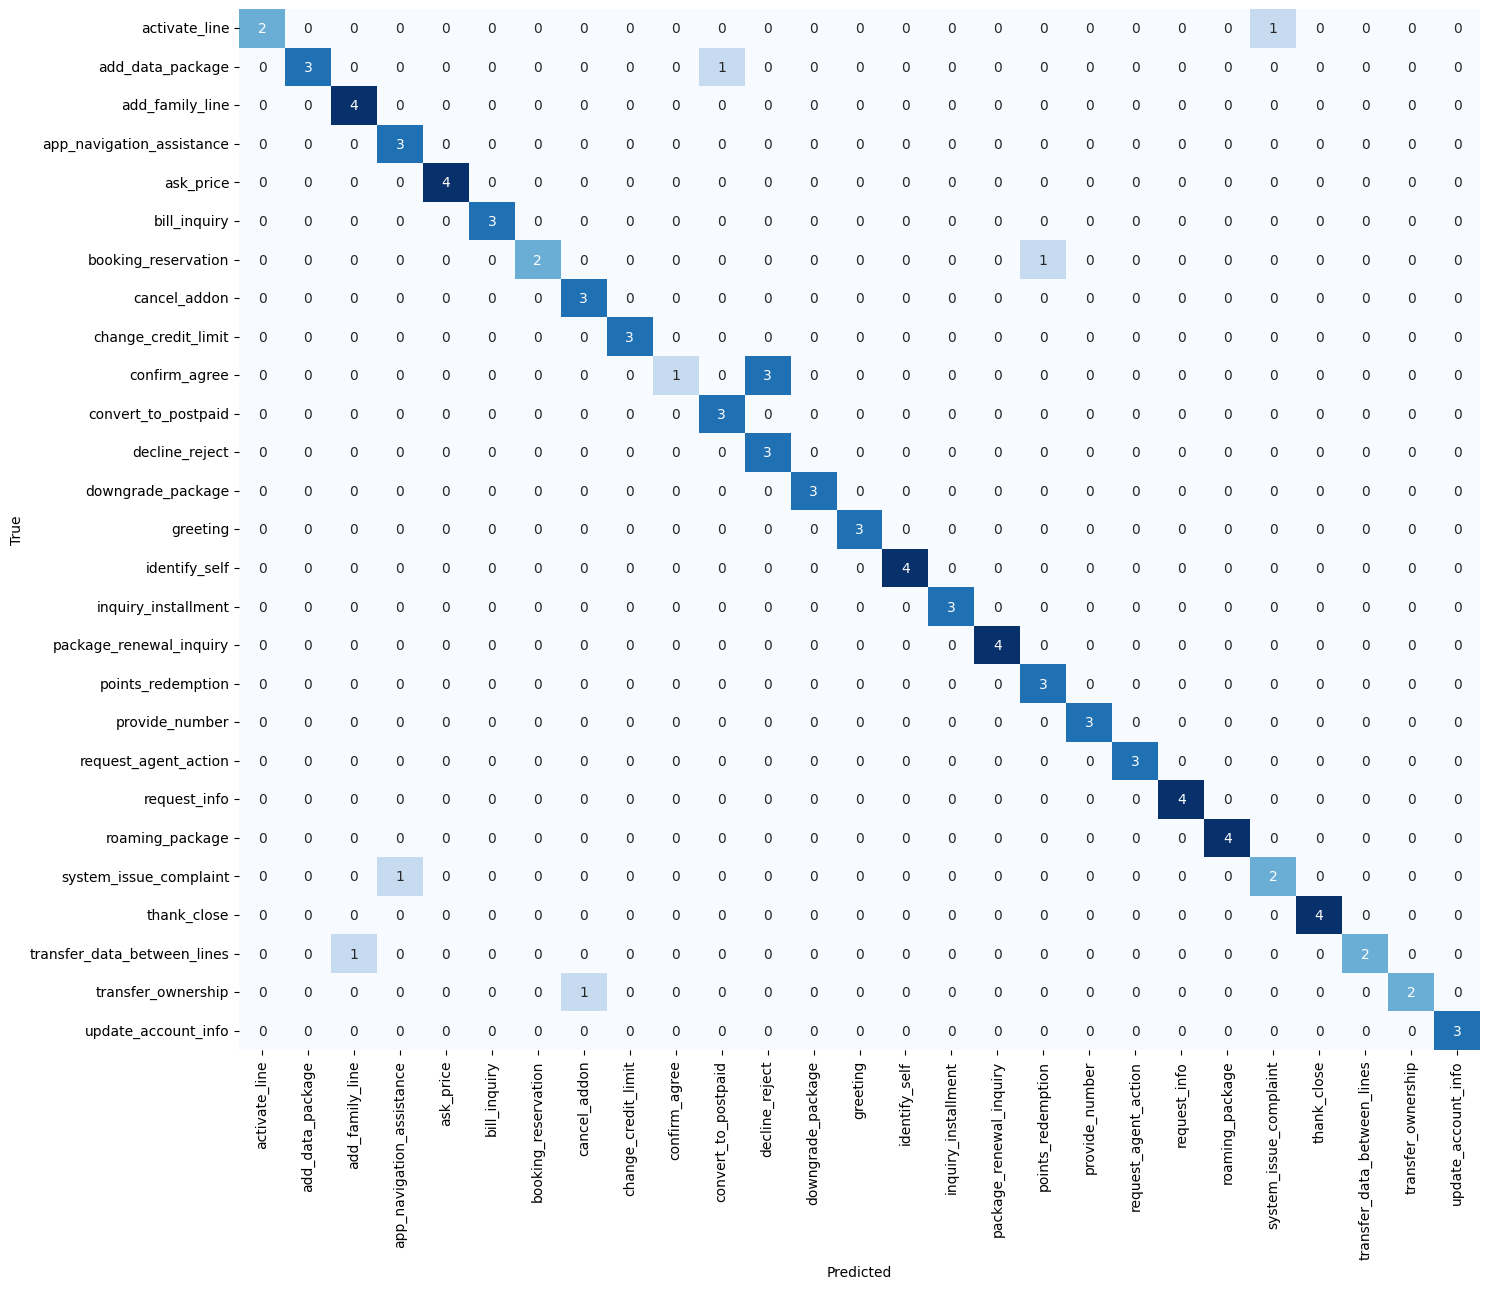

In [11]:
cm = confusion_matrix(true_labels, pred_labels, labels=INTENTS)

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=INTENTS, yticklabels=INTENTS,
            cmap="Blues", ax=ax, cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Confusion analysis — three worst intents

In [12]:
report_dict = classification_report(
    true_labels, pred_labels, labels=INTENTS, output_dict=True, zero_division=0
)
per_intent_f1 = pd.Series({intent: report_dict[intent]["f1-score"] for intent in INTENTS})
worst_three = per_intent_f1.sort_values().head(3)
print("Three worst intents by F1:")
print(worst_three)

val_df_reset = val_df.reset_index(drop=True)
print("\n========== ERRORS FOR THE THREE WORST INTENTS ==========")
for intent in worst_three.index:
    print(f"\n--- {intent} (F1={worst_three[intent]:.3f}) ---")
    mask = (true_labels == intent) & (pred_labels != intent)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        print("  (no true-label errors for this intent on the val set)")
    else:
        for i in idxs:
            row = val_df_reset.iloc[i]
            print(f"  '{row['customer_text']}'  ->  predicted: {pred_labels[i]}  (raw: '{raw_outputs[i]}')")


Three worst intents by F1:
confirm_agree             0.400000
decline_reject            0.666667
system_issue_complaint    0.666667
dtype: float64

========== ERRORS FOR THE THREE WORST INTENTS ==========

--- confirm_agree (F1=0.400) ---
  'ماشي'  ->  predicted: decline_reject  (raw: 'decline_reject')
  'معلش ماشي ابعتها يا ريت'  ->  predicted: decline_reject  (raw: 'decline_reject')
  'ماشي موافق'  ->  predicted: decline_reject  (raw: 'decline_reject')

--- decline_reject (F1=0.667) ---
  (no true-label errors for this intent on the val set)

--- system_issue_complaint (F1=0.667) ---
  'مش عارف اسجل دخول في تطبيق ماي إي اند مصر'  ->  predicted: app_navigation_assistance  (raw: 'app_navigation_assistance')


## 10. Latency Benchmark

In [13]:
bench_text = val_df.iloc[0]["customer_text"]

# warm-up
for _ in range(20):
    _ = predict_intent_llm(bench_text)

n_runs = 30
timings = []
for _ in range(n_runs):
    start = time.perf_counter()
    _ = predict_intent_llm(bench_text)
    timings.append((time.perf_counter() - start) * 1000)

timings = np.array(timings)
print(f"Hardware: {DEVICE.upper()}")
print(f"Batch size: 1, warm-up runs: 20, timed runs: {n_runs}")
print(f"Median latency: {np.median(timings):.1f} ms")
print(f"p95 latency:    {np.percentile(timings, 95):.1f} ms")
print(f"Mean latency:   {timings.mean():.1f} ms")


Hardware: CUDA
Batch size: 1, warm-up runs: 20, timed runs: 30
Median latency: 2567.7 ms
p95 latency:    2581.3 ms
Mean latency:   2568.9 ms


## 12. Held-Out Test Evaluation

In [14]:
test_true, test_pred, test_raw = [], [], []

for _, row in test_df.iterrows():
    pred, raw = predict_intent_llm(row["customer_text"], row.get("agent_text", ""))
    test_true.append(row["intent"])
    test_pred.append(pred)
    test_raw.append(raw)

test_true = np.array(test_true)
test_pred = np.array(test_pred)

test_macro_f1 = f1_score(test_true, test_pred, average="macro")
test_accuracy = accuracy_score(test_true, test_pred)

print("=== HELD-OUT TEST RESULTS (scored once) ===")
print(f"Macro F1:  {test_macro_f1:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print()
print(classification_report(test_true, test_pred, labels=INTENTS, digits=3, zero_division=0))

test_fuzzy_rate = fallback_counter["fuzzy_fallback_used"] / max(fallback_counter["total_calls"], 1)
print(f"\nCumulative fuzzy-match fallback rate (val + test calls so far): {test_fuzzy_rate:.1%}")

# needed by the summary cell computed here, not left as text-only output
test_report_dict = classification_report(
    test_true, test_pred, labels=INTENTS, output_dict=True, zero_division=0
)
test_report_df = pd.DataFrame(test_report_dict).T
test_size = len(test_df)  # locked in now, before the blind-test cell can overwrite test_df

# aliases for the final summary cell
macro_f1_test = test_macro_f1
accuracy_test = test_accuracy

=== HELD-OUT TEST RESULTS (scored once) ===
Macro F1:  0.9101
Accuracy:  0.9341

                             precision    recall  f1-score   support

              activate_line      1.000     1.000     1.000         3
           add_data_package      1.000     1.000     1.000         4
            add_family_line      0.600     1.000     0.750         3
  app_navigation_assistance      0.750     1.000     0.857         3
                  ask_price      1.000     1.000     1.000         3
               bill_inquiry      1.000     1.000     1.000         4
        booking_reservation      1.000     1.000     1.000         4
               cancel_addon      1.000     1.000     1.000         4
        change_credit_limit      1.000     0.750     0.857         4
              confirm_agree      1.000     0.333     0.500         3
        convert_to_postpaid      1.000     1.000     1.000         3
             decline_reject      1.000     1.000     1.000         3
          downgrade_p

In [15]:
worst_three_test_names = (
    test_report_df.drop(index=["accuracy", "macro avg", "weighted avg"])["f1-score"]
    .sort_values()
    .head(3)
    .index
)

test_df_reset = test_df.reset_index(drop=True)
print("\n========== ERRORS FOR THE THREE WORST INTENTS (HELD-OUT TEST) ==========")
for intent in worst_three_test_names:
    print(f"\n--- {intent} ---")
    mask = (test_true == intent) & (test_pred != intent)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        print("  (no true-label errors for this intent on the test set)")
    else:
        for i in idxs:
            row = test_df_reset.iloc[i]
            print(f"  '{row['customer_text']}'  ->  predicted: {test_pred[i]}  (raw: '{test_raw[i]}')")


========== ERRORS FOR THE THREE WORST INTENTS (HELD-OUT TEST) ==========

--- transfer_data_between_lines ---
  'معلش عايز اهدي نت لزوجي بجد'  ->  predicted: add_family_line  (raw: 'add_family_line')
  'بصراحه عايز احول نت لخط اهلي وهما بره البلد لو ينفع'  ->  predicted: transfer_ownership  (raw: 'transfer_ownership')
  'عايز اهدي نت لبنتي بجد'  ->  predicted: add_family_line  (raw: 'add_family_line')

--- confirm_agree ---
  'معلش اه لو سمحت'  ->  predicted: thank_close  (raw: 'thank_close')
  'لو سمحت تمام خالص كده حاضر يا فندم'  ->  predicted: thank_close  (raw: 'thank_close')

--- thank_close ---
  (no true-label errors for this intent on the test set)


## 13. Inference on the Blind Test Set

In [ ]:
BLIND_TEST_PATH = "blind_test.jsonl"  # replace with the real path once supplied
import os

if os.path.exists(BLIND_TEST_PATH):
    blind_df = load_jsonl(BLIND_TEST_PATH)
    preds = []
    for _, row in blind_df.iterrows():
        pred, _ = predict_intent_llm(row["customer_text"], row.get("agent_text", ""))
        preds.append(pred)
    with open("predictions_trackC.txt", "w", encoding="utf-8") as f:
        for p in preds:
            f.write(p + "\n")
    print(f"Wrote {len(preds)} predictions to predictions_trackC.txt")
else:
    print(f"'{BLIND_TEST_PATH}' not found yet -- this cell will run once the blind test file is provided.")

## 14. Save the Prompt Template

In [16]:
with open("prompt_template.txt", "w", encoding="utf-8") as f:
    f.write(SYSTEM_PROMPT)
print("Saved prompt_template.txt")


Saved prompt_template.txt


## 15. One-page Evaluation Summary

In [17]:
worst_three_test = (
    test_report_df.drop(index=["accuracy", "macro avg", "weighted avg"])["f1-score"]
    .sort_values()
    .head(3)
)

summary = f"""
EVALUATION SUMMARY -- Egyptian Arabic Intent Classification (Track C: Few-Shot Prompting)
================================================================================
Model:               {MODEL_NAME} (4-bit)

--- VALIDATION SET (tuned iteratively) ---
Val size:             {len(val_df)}
Macro F1:             {macro_f1_val:.3f}
Accuracy:             {accuracy_val:.3f}

--- HELD-OUT TEST SET (scored once, no further tuning after seeing this) ---
Test size:            {test_size}
Macro F1:             {macro_f1_test:.3f}
Accuracy:             {accuracy_test:.3f}

Three worst intents on held-out test (by F1):
{chr(10).join(f"  - {intent}: {score:.3f}" for intent, score in worst_three_test.items())}

Note on the val/test gap: val macro F1 reached {macro_f1_val:.3f} after iterative
prompt refinement against val errors, but held-out test macro F1 was {macro_f1_test:.3f}
-- a drop of {macro_f1_val - macro_f1_test:.3f}. This gap is expected: several rules and
few-shot examples were added specifically in response to val-set errors, so some
of the val-set gain reflects fitting to that particular set rather than a fully
general rule. The held-out test score above is the more honest estimate of
real-world performance.

Latency (batch=1, {DEVICE.upper()}, median of {n_runs} runs after 20 warm-up):
  {np.median(timings):.1f} ms

Constrained-output handling:
  Fuzzy-match fallback fired on {test_fuzzy_rate:.1%} of calls (cumulative val+test)
  Fully unparseable outputs: {fallback_counter['unparseable']}

Overlapping-intent rules applied (see prompt Rules section):
  1. identify_self vs provide_number         -> full name vs bare digits
  2. app_navigation_assistance vs system_issue_complaint -> "where/how" vs "broken"
  3. bill_inquiry vs ask_price                -> already charged vs cost up front
  4. inquiry_installment vs ask_price/bill_inquiry -> installment topic always wins
  5. ask_price vs roaming_package             -> flat rate/cost vs plan choice/availability
  6. package_renewal_inquiry vs roaming_package -> renewal of a roaming package stays roaming_package
  7. cancel_addon vs package_renewal_inquiry  -> cancel an add-on vs cancel auto-renewal
  8. update_account_info vs change_credit_limit -> contact/ID info vs credit limit specifically
  9. add_family_line vs transfer_ownership    -> swapping plan membership vs changing line ownership
  10. request_info                            -> fallback only, never the default guess
  11. "خالص" and similar intensifiers carry no polarity -> judged by explicit agree/negate words
================================================================================
"""
print(summary)

with open("evaluation_summary_trackC.txt", "w", encoding="utf-8") as f:
    f.write(summary)


EVALUATION SUMMARY -- Egyptian Arabic Intent Classification (Track C: Few-Shot Prompting)
Model:               Qwen/Qwen2.5-7B-Instruct (4-bit)

--- VALIDATION SET (tuned iteratively) ---
Val size:             90
Macro F1:             0.893
Accuracy:             0.900

--- HELD-OUT TEST SET (scored once, no further tuning after seeing this) ---
Test size:            91
Macro F1:             0.910
Accuracy:             0.934

Three worst intents on held-out test (by F1):
  - transfer_data_between_lines: 0.000
  - confirm_agree: 0.500
  - thank_close: 0.750

Note on the val/test gap: val macro F1 reached 0.893 after iterative
prompt refinement against val errors, but held-out test macro F1 was 0.910
-- a drop of -0.017. This gap is expected: several rules and
few-shot examples were added specifically in response to val-set errors, so some
of the val-set gain reflects fitting to that particular set rather than a fully
general rule. The held-out test score above is the more honest estimat